# EDA — Поиск статей справки (Articles-Retrieval)

Разведочный анализ трёх файлов задачи:

1. **`articles.f`** — корпус статей справки (`article_id`, `title`, `body` в HTML).
2. **`calibration.f`** — размеченные запросы (`query_id`, `query_text`, `ground_truth`).
3. **`test.f`** — запросы без разметки (`query_id`, `query_text`).

Цель анализа — понять структуру данных и характер шума, чтобы спроектировать
этап поиска (retrieval) под метрику **MAP@10**.

## 0. Настройка и загрузка данных

In [1]:
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"  # поддерживает кириллицу
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

DATA_DIR = Path("../data/candidate_data")
articles = pd.read_feather(DATA_DIR / "articles.f")
calibration = pd.read_feather(DATA_DIR / "calibration.f")
test = pd.read_feather(DATA_DIR / "test.f")

print("articles   ", articles.shape)
print("calibration", calibration.shape)
print("test       ", test.shape)

articles    (793, 3)
calibration (500, 3)
test        (500, 2)


In [2]:
# Вспомогательные функции очистки HTML -> текст

def html_to_text(html: str) -> str:
    """Грубая, но быстрая очистка HTML в plain-текст."""
    if not isinstance(html, str) or not html:
        return ""
    soup = BeautifulSoup(html, "lxml")
    # уберём то, что почти наверняка не несёт смысла для поиска
    for tag in soup(["script", "style"]):
        tag.decompose()
    text = soup.get_text(separator=" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def count_words(s: str) -> int:
    return len(re.findall(r"\w+", s or "", flags=re.UNICODE))

## 1. `articles.f` — корпус статей

Ключевые вопросы:
- Сколько статей, уникальны ли `article_id`, есть ли пропуски/дубли?
- Насколько длинные заголовки и тела статей (в сыром HTML и после очистки)?
- Какая HTML-разметка встречается (табы, спойлеры, таблицы) — что придётся чистить?
- Есть ли внутренние ссылки между статьями (`support.avito.ru/articles/...`)?

In [3]:
articles.head(5)

,article_id,title,body
0,1730,Имя или название компании,"<ol><li><p>Зайдите в раздел <a href=""https://www.avito.ru/profile/extended"">Управление профилем</a>.</p><ol start=""2..."
1,1746,"Понять, что профиль заблокирован","<p>Проверьте, какое сообщение вы видите при входе в профиль.</p><div class=""tabset tabset_155""><input type=""radio"" n..."
2,1747,Не допустить блокировки профиля,<ol><li><p><strong>Не заводите несколько аккаунтов для продаж в одной категории. </strong>Так поступают пользователи...
3,1774,Оставить или удалить профиль,"<p>⚡ Не удаляйте профиль с подтверждёнными данными: проверку можно пройти только один раз, в другом профиле уже не п..."
4,1775,Удалить профиль,"<p>⚡ Удалить профиль не получится, если у вас есть незавершённые сделки или бронирования, неоплаченные услуги или до..."


In [4]:
print("shape:", articles.shape)
print("\ndtypes:\n", articles.dtypes)
print("\nпропуски по колонкам:\n", articles.isna().sum())
print("\nдубли article_id:", articles["article_id"].duplicated().sum())
print("уникальных article_id:", articles["article_id"].nunique())
print("диапазон article_id: [%d .. %d]" % (articles["article_id"].min(), articles["article_id"].max()))
print("\nдубли title:", articles["title"].duplicated().sum())
print("пустых/NA body:", (articles["body"].fillna("").str.len() == 0).sum())

shape: (793, 3)

dtypes:
 article_id             int64
title         string[python]
body          string[python]
dtype: object

пропуски по колонкам:
 article_id    0
title         0
body          0
dtype: int64

дубли article_id: 0
уникальных article_id: 793
диапазон article_id: [1730 .. 4551]

дубли title: 92
пустых/NA body: 0


In [5]:
# Граф внутренних ссылок: статьи ссылаются друг на друга -> потенциальный сигнал
link_re = re.compile(r"support\.avito\.ru/articles/(\d+)")
out_links = {}
all_ids = set(articles["article_id"])
for aid, html in zip(articles["article_id"], articles["body"].fillna("")):
    ids = {int(x) for x in link_re.findall(html)}
    ids.discard(aid)
    out_links[aid] = ids & all_ids  # только ссылки на статьи из нашего корпуса

n_with_links = sum(1 for v in out_links.values() if v)
total_edges = sum(len(v) for v in out_links.values())
indeg = Counter()
for v in out_links.values():
    for t in v:
        indeg[t] += 1

print(f"Статей с внутренними ссылками на корпус: {n_with_links} / {len(articles)}")
print(f"Всего рёбер (ссылок внутри корпуса):      {total_edges}")
print("\nЧаще всего ссылаются на (article_id -> входящих ссылок):")
for aid, n in indeg.most_common(10):
    title = articles.loc[articles.article_id == aid, "title"].values[0]
    print(f"  {aid:5d}  in={n:3d}  {title[:60]}")

Статей с внутренними ссылками на корпус: 380 / 793
Всего рёбер (ссылок внутри корпуса):      924

Чаще всего ссылаются на (article_id -> входящих ссылок):
   2324  in= 52  Как подтвердить данные в профиле
   2214  in= 33  Получить значок «Реквизиты проверены»
   2095  in= 26  Что такое тариф
   2699  in= 25  Персональный менеджер
   4321  in= 19  Мой уровень сервиса
   2147  in= 17  Выделение цветом
   2148  in= 17  XL-объявление
   2057  in= 14  Правила для отзывов
   2215  in= 13  Получить значок «Документы проверены»
   1870  in= 12  Установить надёжный пароль


In [8]:
articles["body_text"] = articles["body"].map(html_to_text)

In [11]:
# Прочитать статью по article_id: заголовок + ПОЛНЫЙ сырой HTML и очищенный текст
def show_article(article_id: int, clip=None):
    """Печатает title, сырой HTML и очищенный текст статьи по её article_id.
    clip=None — показать целиком; clip=N — первые N символов."""
    row = articles.loc[articles["article_id"] == article_id]
    if row.empty:
        print(f"article_id {article_id} не найден в корпусе")
        return
    row = row.iloc[0]                     # DataFrame -> Series (иначе печатается вся колонка)
    raw = row["body"]
    cut = (lambda s: s if clip is None else s[:clip])
    print("article_id:", row["article_id"])
    print("title:", row["title"])
    print("\n--- СЫРОЙ HTML ---")
    print(cut(raw))
    print("\n--- ОЧИЩЕННЫЙ ТЕКСТ ---")
    print(cut(html_to_text(raw)))          # чистим на лету, колонка body_text не нужна


show_article(4400)          # любой id, напр. show_article(4219) или show_article(1951, clip=500)

article_id: 4400
title: Покупателю — отказаться от товара или вернуть его

--- СЫРОЙ HTML ---
<headline name="Отказаться от товара при получении" id="1965"><h2>Отказаться от товара при получении</h2></headline><div class="factoid factoid_disclaimer"><p>Отказаться от товара можно только при получении, если на товаре нет значка со сроком на возврат, например, <strong>14 дней на возврат</strong>. Значок «3/7/14 дней на возврат» означает, что товар можно проверить в течение этого времени, и если он не подойдет — вернуть продавцу через Авито. </p></div><div class="factoid factoid_disclaimer"><p>Если заказ через постамат или кассу 5Post — забрать товар нужно в любом случае, даже если он <a href="https://support.avito.ru/articles/2505">повреждён или не подошёл</a>.</p></div><p>⚡️Если на товаре есть значок «3/7/14 дней на возврат» — <strong><a href="https://support.avito.ru/articles/4219#2817">деньги вернутся</a></strong> на вашу карту или кошелёк в течение 5 рабочих дней после того, как прода

## 2. `calibration.f` — размеченные запросы

Ключевые вопросы:
- Как выглядят запросы: длина, стиль (разговорный, опечатки)?
- Сколько правильных статей приходится на запрос (`ground_truth`)?
- Все ли `ground_truth`-id присутствуют в `articles.f`?
- Есть ли «популярные» статьи-ответы (перекос распределения)?

In [ ]:
print("shape:", calibration.shape)
print("\nпропуски:\n", calibration.isna().sum())
print("\nдубли query_id:", calibration["query_id"].duplicated().sum())
print("дубли query_text:", calibration["query_text"].duplicated().sum())

calibration = calibration.copy()
calibration["q_len_chars"] = calibration["query_text"].str.len()
calibration["q_len_words"] = calibration["query_text"].map(count_words)
calibration["gt_ids"] = calibration["ground_truth"].str.split()
calibration["n_gt"] = calibration["gt_ids"].map(len)

print("\nдлина запроса (слов):")
print(calibration["q_len_words"].describe().round(1))

shape: (500, 3)

пропуски:
 query_id        0
query_text      0
ground_truth    0
dtype: int64

дубли query_id: 0
дубли query_text: 0

длина запроса (слов):
count    500.0
mean      11.6
std        5.3
min        3.0
25%        7.0
50%       10.0
75%       15.0
max       27.0
Name: q_len_words, dtype: float64


In [ ]:
# Сколько правильных статей на запрос
print("Распределение числа правильных статей на запрос:")
print(calibration["n_gt"].value_counts().sort_index())
print("\nсреднее:", round(calibration["n_gt"].mean(), 2),
      "| медиана:", int(calibration["n_gt"].median()),
      "| максимум:", int(calibration["n_gt"].max()))
print("Запросов с >1 правильной статьёй: %d (%.1f%%)" % (
    (calibration["n_gt"] > 1).sum(), (calibration["n_gt"] > 1).mean() * 100))

Распределение числа правильных статей на запрос:
n_gt
1    279
2    182
3     38
4      1
Name: count, dtype: int64

среднее: 1.52 | медиана: 1 | максимум: 4
Запросов с >1 правильной статьёй: 221 (44.2%)


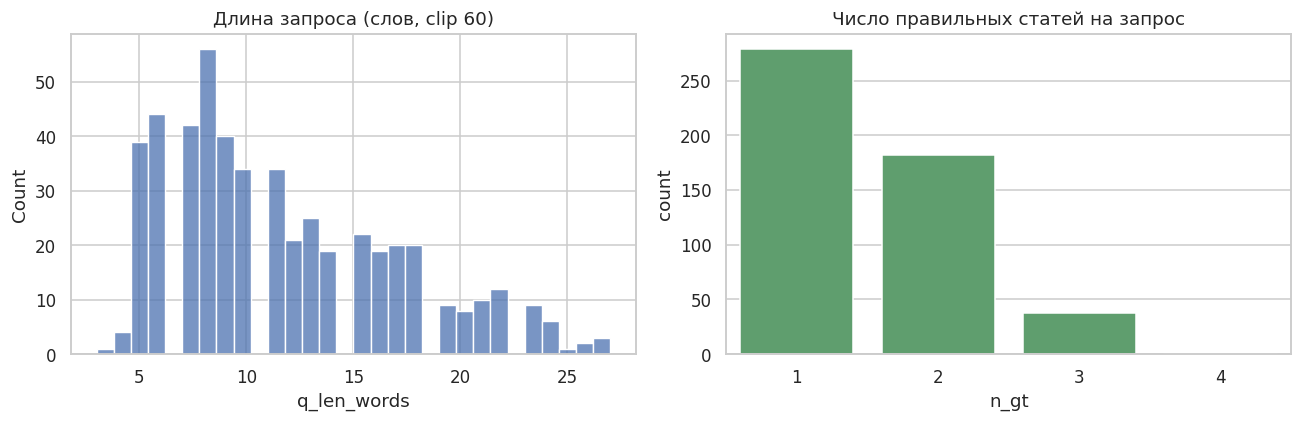

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(calibration["q_len_words"].clip(upper=60), bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Длина запроса (слов, clip 60)")
sns.countplot(x=calibration["n_gt"], ax=axes[1], color="#55A868")
axes[1].set_title("Число правильных статей на запрос")
plt.tight_layout(); plt.show()

In [ ]:
# Проверка целостности: все ли ground_truth id есть в корпусе?
all_ids = set(articles["article_id"].astype(str))
gt_flat = [i for ids in calibration["gt_ids"] for i in ids]
gt_unique = set(gt_flat)
missing = gt_unique - all_ids
print("Уникальных статей в разметке:", len(gt_unique))
print("Отсутствуют в articles.f:", len(missing), sorted(missing)[:20])
print("Доля корпуса, покрытая разметкой: %.1f%%" % (len(gt_unique & all_ids) / len(all_ids) * 100))

print("\nТОП-10 самых частых правильных статей (calibration):")
for aid, n in Counter(gt_flat).most_common(10):
    title = articles.loc[articles.article_id == int(aid), "title"]
    title = title.values[0] if len(title) else "??"
    print(f"  {aid:>5}  x{n:2d}  {title[:60]}")

Уникальных статей в разметке: 79
Отсутствуют в articles.f: 0 []
Доля корпуса, покрытая разметкой: 10.0%

ТОП-10 самых частых правильных статей (calibration):
   4219  x129  Покупателю
   1951  x73  Кто оплачивает доставку и сколько она стоит
   4234  x63  Как продавать и покупать с доставкой
   2646  x57  Оплата заказов с доставкой
   4328  x39  Что можно заказать и отправить
   4400  x33  Покупателю — отказаться от товара или вернуть его
   4214  x31  Скидки, бонусы и промокоды
   4384  x26  Баланс для покупок
   4440  x26  Платёж прошёл, но есть проблема
   4387  x21  Всё про отмену заказа


In [ ]:
# Примеры запросов вместе с заголовками правильных статей
id2title = dict(zip(articles["article_id"].astype(str), articles["title"]))
for _, r in calibration.head(6).iterrows():
    print(f"[{r['query_id']}] {r['query_text']}")
    for gid in r["gt_ids"]:
        print(f"      -> {gid}: {id2title.get(gid, '??')}")
    print()

[1] Как передать товар через службу авито
      -> 1909: Отправить заказ
      -> 4234: Как продавать и покупать с доставкой

[2] Можете подсказать, если заказать товар Авито доставкой и оплатить также через авито, в случае возврата товара деньги безусловно мне возвращаются?
      -> 2865: Когда вернутся деньги за доставку
      -> 4400: Покупателю — отказаться от товара или вернуть его

[3] Здравствуйте. Как отправить товар через Авито.
      -> 1909: Отправить заказ

[4] как получить деньги за возрат если продавец уже забрал товар?
      -> 4400: Покупателю — отказаться от товара или вернуть его
      -> 4403: Продавцу — товар не забирают или вернули

[5] Когда мне прийдут деньги за доставку, сегодня уже <DATE>
      -> 4361: Продавцу

[6] Почему пишете что доставка <MONEY> а когда оплачиваешь получается больше <MONEY>?
      -> 1951: Кто оплачивает доставку и сколько она стоит



## 3. `test.f` — целевые запросы

Ключевые вопросы:
- Совпадает ли распределение длин/стиля с `calibration` (можно ли доверять калибровке)?
- Есть ли дубли запросов или пересечения с `calibration`?

In [ ]:
print("shape:", test.shape)
print("\nпропуски:\n", test.isna().sum())
print("\nдубли query_id:", test["query_id"].duplicated().sum())
print("дубли query_text:", test["query_text"].duplicated().sum())

test = test.copy()
test["q_len_chars"] = test["query_text"].str.len()
test["q_len_words"] = test["query_text"].map(count_words)
print("\nдлина запроса (слов):")
print(test["q_len_words"].describe().round(1))

shape:

 (500, 2)

пропуски:
 query_id      0
query_text    0
dtype: int64

дубли query_id: 0
дубли query_text: 0

длина запроса (слов):
count    500.0
mean      11.8
std        6.5
min        2.0
25%        7.0
50%       10.0
75%       15.0
max       44.0
Name: q_len_words, dtype: float64


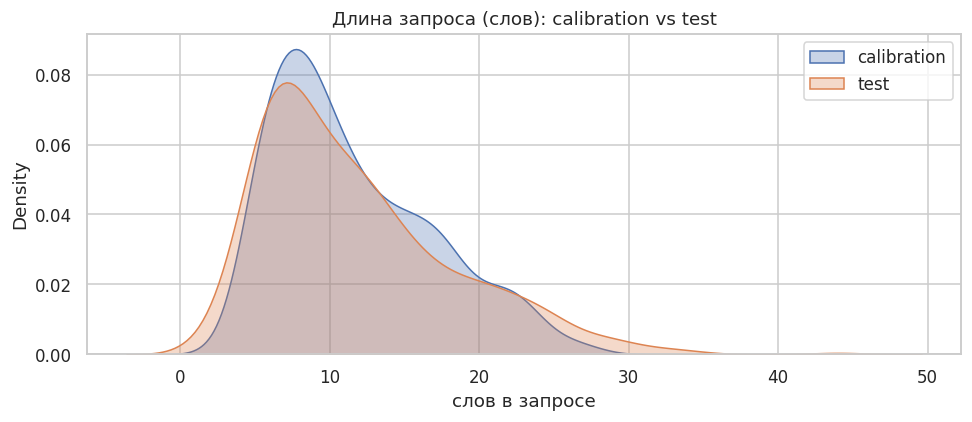

Средняя длина (слов): calibration=11.6, test=11.8


In [ ]:
# Сравнение распределения длин test vs calibration
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(calibration["q_len_words"].clip(upper=60), label="calibration", fill=True, alpha=.3, ax=ax)
sns.kdeplot(test["q_len_words"].clip(upper=60), label="test", fill=True, alpha=.3, ax=ax)
ax.set_title("Длина запроса (слов): calibration vs test")
ax.set_xlabel("слов в запросе"); ax.legend()
plt.tight_layout(); plt.show()

print("Средняя длина (слов): calibration=%.1f, test=%.1f" % (
    calibration["q_len_words"].mean(), test["q_len_words"].mean()))

In [ ]:
# Пересечения текстов запросов между test и calibration
overlap = set(test["query_text"]) & set(calibration["query_text"])
print("Одинаковых query_text в test и calibration:", len(overlap))

print("\nПримеры тестовых запросов:")
for _, r in test.head(8).iterrows():
    print(f"  [{r['query_id']}] {r['query_text']}")

Одинаковых query_text в test и calibration: 0

Примеры тестовых запросов:
  [1] Здравствуйте! Подскажите, пожалуйста, не могу оформить доставку , какие-то проблемы с приложением?
  [2] Здравствуйте , почему так долго доставляется возврат? В приложении СДЭКА пишет то что посылка вручена, а на Авито до сих пор то что заказ едет ?
  [3] Здравствуйте,подскажите как мне отправить кроссовки покупателю через пункт «Авито»?
  [4] Здравствуйте! В каких случаях за возврат снимают деньги за доставку у покупателя?
  [5] Почему у меня доставки в несколько раз дороже с данного аккаунта чем с другого на одни и те же товары
  [6] поменять реквизиты
  [7] Моя посылка едет к продавцу,деньги мне вернут только,когда заберёт посылку
  [8] Почему доставка стоит больше чем заказ?


## 4. Выводы для этапа поиска

*(раздел заполняется по результатам выполнения ячеек выше)*

Ориентиры, которые проверяем в анализе:

- **Корпус небольшой** (~800 статей) — можно позволить тяжёлые модели/переранжирование.
- **HTML нужно чистить**: таблицы, табы, спойлеры, factoid-блоки, картинки; заголовок
  (`title`) — важный короткий сигнал, тело — длинный.
- **У многих запросов несколько правильных статей** → метрика MAP@10 вознаграждает
  за то, чтобы собрать *все* релевантные документы вверху, а не только один.
- **Запросы разговорные, с опечатками** → лексический матч (BM25) страдает от
  несовпадения лексики; вероятно, нужен семантический поиск (эмбеддинги) +
  возможен гибрид.
- **Внутренние ссылки между статьями** — потенциальный дополнительный сигнал для
  добора связанных документов.
- Распределения длин **test ≈ calibration**, значит калибровке можно доверять как
  прокси качества.